<a href="https://colab.research.google.com/github/adhammkhaled/Pattern-Recognition-Labs/blob/main/Style%20Transfer/cnn_style_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 03

  Style Transfer with Multi-Input Conditioning:
In this assignment, you will implement a neural style transfer pipeline that takes two input images
and a style threshold:
- A content image, such as a photograph of a city or a person
- A style image, such as a painting by Van Gogh or Picasso
- The style threshold is a scalar value that determines the degree to which the style is
transferred onto the content image


Your model will generate a new image that preserves the content of the first image while adopting
the style of the second, modulated by the threshold value. To understand the underlying principles
of neural style transfer, you are expected to read the foundational paper on this topic https://openaccess.thecvf.com/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf

## **Part One**

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import os
import random
from sklearn.model_selection import train_test_split
from PIL import Image
import shutil

### 1.1. Downloading

In [3]:
# downloading WikiArt style dataset
style_path = kagglehub.dataset_download("steubk/wikiart")
print("WikiArt style images saved to:", style_path)

# downloading content image dataset
content_path = kagglehub.dataset_download("duttadebadri/image-classification")
print("Content images saved to:", content_path)

content_path = os.path.join(content_path, "images", "images")



WikiArt style images saved to: /kaggle/input/wikiart
Content images saved to: /kaggle/input/image-classification


In [4]:
print(os.listdir(content_path))
print("\n")
print(os.listdir(style_path))

['food and d rinks', 'travel and  adventure', 'art and culture', 'architecure']


['Pop_Art', 'Minimalism', 'Color_Field_Painting', 'Mannerism_Late_Renaissance', 'Symbolism', 'Impressionism', 'Contemporary_Realism', 'High_Renaissance', 'Fauvism', 'Rococo', 'Early_Renaissance', 'Naive_Art_Primitivism', 'Pointillism', 'classes.csv', 'Cubism', 'Synthetic_Cubism', 'Action_painting', 'Abstract_Expressionism', 'New_Realism', 'wclasses.csv', 'Baroque', 'Analytical_Cubism', 'Expressionism', 'Romanticism', 'Northern_Renaissance', 'Ukiyo_e', 'Post_Impressionism', 'Art_Nouveau_Modern', 'Realism']


In [5]:
content_image_count = 0
for root, _, files in os.walk(content_path):
    content_image_count += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"Number of content images: {content_image_count}")




Number of content images: 35093


In [6]:
style_image_count = 0
for subfolder in os.listdir(style_path):
    subfolder_path = os.path.join(style_path, subfolder)
    if os.path.isdir(subfolder_path):
        style_image_count += len([
            f for f in os.listdir(subfolder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
print(f"Number of style images: {style_image_count}")

Number of style images: 81444


### 1.2. Splitting

In [7]:
# 1. Collect content and style image paths
def get_image_paths(root_dir, limit=None):
    image_paths = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    random.shuffle(image_paths)  # shuffle to get diverse categories
    if limit:
        image_paths = image_paths[:limit]
    return image_paths

content_images = get_image_paths(content_path, limit=5000)
style_images = get_image_paths(style_path, limit=5000)

print(f"Selected content images: {len(content_images)}")
print(f"Selected style images: {len(style_images)}")

# 2. Split into train/val/test
def split_data(images):
    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)
    return train, val, test

content_train, content_val, content_test = split_data(content_images)
style_train, style_val, style_test = split_data(style_images)

# 3. Copy images to new folders
def copy_images(images, base_dir, label):
    for img_path in images:
        filename = os.path.basename(img_path)
        dest_dir = os.path.join(base_dir, label)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(img_path, os.path.join(dest_dir, filename))

base_output = "/content/dataset_split"

# Create folders like /content/dataset_split/content/train, etc.
for split, data in zip(
    ['train', 'val', 'test'],
    [content_train, content_val, content_test]
):
    copy_images(data, os.path.join(base_output, 'content'), split)

for split, data in zip(
    ['train', 'val', 'test'],
    [style_train, style_val, style_test]
):
    copy_images(data, os.path.join(base_output, 'style'), split)

print("Done, dataset is split and stored under /content/dataset_split")


Selected content images: 5000
Selected style images: 5000
Done, dataset is split and stored under /content/dataset_split


In [8]:
def count_images_in_split(base_path, label):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, label, split)
        num_images = len([
            f for f in os.listdir(split_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"{label.capitalize()} - {split}: {num_images} images")

# Check content
count_images_in_split("/content/dataset_split", "content")

# Check style
count_images_in_split("/content/dataset_split", "style")


Content - train: 3486 images
Content - val: 748 images
Content - test: 749 images
Style - train: 3499 images
Style - val: 750 images
Style - test: 750 images


## **Part Two : Data Preprocessing**

In [9]:
import random
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
from PIL import UnidentifiedImageError


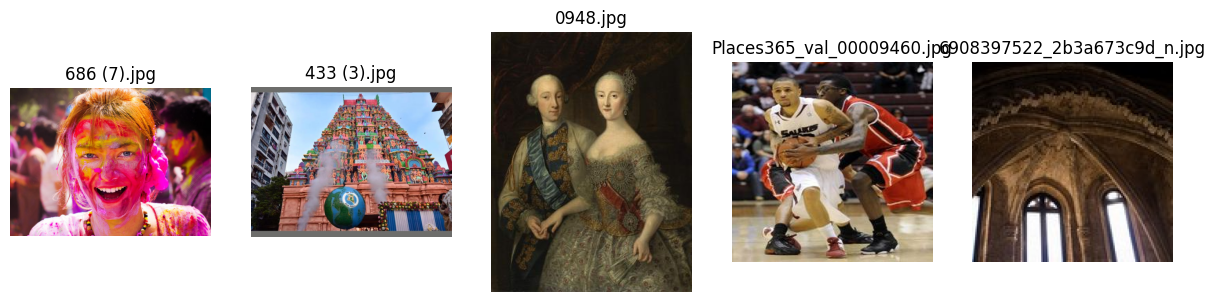

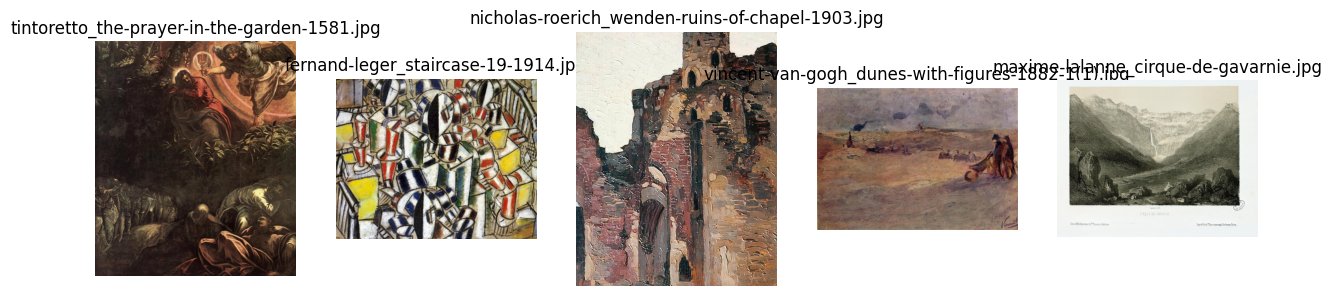

In [10]:
# random images from the dataset split (train/val/test)
def show_images_from_split(split_dir, num_images=5):
    # all image files in the split directory
    image_files = [f for f in os.listdir(split_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    sampled_images = random.sample(image_files, num_images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i, image_name in enumerate(sampled_images):
        img = Image.open(os.path.join(split_dir, image_name))
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(image_name)

    plt.show()


content_train_dir = "/content/dataset_split/content/train"
show_images_from_split(content_train_dir, num_images=5)

print("\n\n")

style_train_dir = "/content/dataset_split/style/train"
show_images_from_split(style_train_dir, num_images=5)


### Checking Corrupted File

In [11]:
from PIL import UnidentifiedImageError

corrupt = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        try:
            img = Image.open(os.path.join(root, file))
            img.verify()  # verifies without loading fully
        except (UnidentifiedImageError, OSError):
            corrupt.append(file)

print(f"Corrupted files: {corrupt}")


Corrupted files: []


Removing the corrupted file

In [12]:
corrupt_file_path = "/content/dataset_split/content/train/Places365_val_00011603.jpg"

if os.path.exists(corrupt_file_path):
    os.remove(corrupt_file_path)
    print(f"Removed: {corrupt_file_path}")
else:
    print(f"File not found: {corrupt_file_path}")


File not found: /content/dataset_split/content/train/Places365_val_00011603.jpg


### Checking Images Sized

In [13]:
sizes = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            img = Image.open(os.path.join(root, file))
            sizes.append(img.size)

from collections import Counter
print(Counter(sizes))  # Shows frequency of each image size


Counter({(256, 256): 898, (128, 128): 851, (320, 320): 413, (320, 240): 118, (100, 100): 45, (321, 240): 28, (1280, 720): 23, (427, 240): 22, (426, 240): 16, (427, 320): 10, (360, 240): 9, (600, 450): 8, (320, 321): 8, (290, 226): 8, (480, 320): 8, (1024, 768): 7, (600, 400): 7, (290, 356): 7, (960, 720): 7, (240, 240): 6, (320, 427): 6, (290, 360): 6, (1024, 683): 5, (600, 600): 5, (290, 361): 5, (759, 422): 5, (290, 365): 5, (650, 400): 5, (320, 400): 5, (480, 360): 5, (290, 377): 5, (800, 533): 4, (800, 600): 4, (647, 404): 4, (290, 330): 4, (290, 376): 4, (290, 387): 4, (1600, 900): 4, (700, 400): 4, (290, 320): 4, (800, 450): 3, (660, 330): 3, (1200, 800): 3, (1000, 1000): 3, (750, 500): 3, (1920, 1200): 3, (2048, 1536): 3, (345, 240): 3, (1024, 680): 3, (728, 546): 3, (640, 360): 3, (450, 300): 3, (1000, 1080): 3, (940, 580): 3, (320, 480): 3, (240, 320): 3, (213, 320): 3, (450, 470): 3, (307, 240): 3, (1300, 956): 3, (276, 320): 3, (261, 240): 2, (290, 338): 2, (462, 363): 2, (6

### Checking Aspect Ratio

In [14]:
ratios = [round(w / h, 2) for w, h in sizes]
print(Counter(ratios))  # common aspect ratios


Counter({1.0: 2260, 1.33: 215, 1.5: 129, 1.78: 98, 1.34: 42, 0.75: 26, 1.51: 26, 0.67: 22, 1.6: 21, 1.49: 20, 0.8: 20, 1.77: 18, 0.81: 17, 1.62: 16, 0.77: 14, 2.0: 13, 1.28: 13, 1.52: 12, 1.67: 12, 1.8: 10, 1.36: 10, 1.4: 9, 1.79: 9, 1.38: 9, 0.79: 9, 1.75: 9, 1.32: 8, 1.43: 8, 0.74: 8, 1.47: 7, 1.54: 7, 0.66: 7, 1.56: 7, 0.71: 7, 0.93: 7, 1.19: 6, 1.48: 6, 1.53: 6, 0.88: 6, 1.72: 6, 0.82: 6, 1.35: 6, 1.69: 6, 0.86: 5, 1.27: 5, 1.59: 5, 1.29: 5, 1.42: 5, 1.45: 5, 1.86: 5, 0.68: 5, 0.91: 5, 1.46: 5, 1.74: 4, 1.87: 4, 1.03: 4, 1.05: 4, 1.57: 4, 1.44: 4, 1.7: 4, 0.69: 4, 1.66: 4, 0.85: 4, 1.58: 4, 1.71: 4, 0.73: 4, 1.22: 4, 1.73: 4, 1.3: 4, 0.63: 4, 0.83: 4, 0.78: 4, 1.02: 4, 1.18: 4, 0.72: 4, 0.96: 4, 1.15: 4, 1.09: 3, 1.64: 3, 1.91: 3, 0.62: 3, 1.41: 3, 1.08: 3, 1.14: 3, 1.24: 3, 0.76: 3, 0.92: 3, 1.31: 3, 0.65: 3, 0.7: 3, 1.9: 3, 1.25: 3, 0.99: 3, 2.12: 3, 1.81: 3, 0.84: 3, 1.55: 3, 3.0: 2, 1.12: 2, 0.94: 2, 2.08: 2, 0.97: 2, 1.06: 2, 1.39: 2, 2.25: 2, 1.63: 2, 1.13: 2, 1.83: 2, 2.17: 

In [15]:
formats = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        ext = os.path.splitext(file)[-1].lower()
        formats.append(ext)

print(Counter(formats))


Counter({'.jpg': 3155, '.jpeg': 209, '.png': 122})


### Checking gray scaled images

In [16]:
grayscale_images = []

for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img = Image.open(os.path.join(root, file))
                if img.mode != 'RGB':
                    grayscale_images.append(file)
            except Exception:
                pass

print(f"Number of grayscale/non-RGB images: {len(grayscale_images)}")
print("Sample grayscale files:", grayscale_images[:5])


Number of grayscale/non-RGB images: 32
Sample grayscale files: ['Places365_val_00007908.jpg', 'Places365_val_00006664.jpg', '315 (5).jpg', '625 (5).jpg', '555.png']


Exists, so will change them to rgb using PIL

In [17]:
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img_path = os.path.join(root, file)
                img = Image.open(img_path)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(img_path)
            except Exception as e:
                print(f"Error processing {file}: {e}")


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [18]:
grayscale_images = []

for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img = Image.open(os.path.join(root, file))
                if img.mode != 'RGB':
                    grayscale_images.append(file)
            except Exception:
                pass

print(f"Number of grayscale/non-RGB images: {len(grayscale_images)}")
print("Sample grayscale files:", grayscale_images[:5])

Number of grayscale/non-RGB images: 0
Sample grayscale files: []


## Starting Preprocessing

In [19]:
IMAGE_SIZE = (256, 256)


In [20]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),  # to [0, 1]
    # Normalization for pretrained VGG (ImageNet stats)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225]),  # ImageNet std


])
# Inverse transform for visualization
inverse_transform = transforms.Compose([
transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                      std=[1/0.229, 1/0.224, 1/0.225]),
transforms.Lambda(lambda x: torch.clamp(x, 0, 1)),  # Clamp to [0,1]
])

In [21]:
def create_preprocessed_sample(content_path, style_path, threshold_range=(0.3, 0.8)):
    content_img = transform(Image.open(content_path).convert("RGB"))
    style_img = transform(Image.open(style_path).convert("RGB"))
    threshold = random.uniform(*threshold_range)
    return content_img, style_img, threshold


In [22]:
class StyleTransferDataset(Dataset):
    def __init__(self, content_paths, style_paths, transform, threshold_range=(0.3, 0.8)):
        self.content_paths = content_paths
        self.style_paths = style_paths
        self.transform = transform
        self.threshold_range = threshold_range

    def __len__(self):
        return len(self.content_paths)

    def __getitem__(self, idx):
        content_img = Image.open(self.content_paths[idx]).convert("RGB")
        style_img = Image.open(random.choice(self.style_paths)).convert("RGB")
        content_tensor = self.transform(content_img)
        style_tensor = self.transform(style_img)
        threshold = random.uniform(*self.threshold_range)
        return content_tensor, style_tensor, threshold


In [23]:
train_dataset = StyleTransferDataset(content_train, style_train, transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = StyleTransferDataset(content_val, style_val, transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)


In [24]:
# show a batch of content + style + threshold
def visualize_batch(dataset, num_samples=5):
    for i in range(num_samples):
        content_img, style_img, threshold = dataset[i]

        # Use your existing inverse transform
        content_denorm = inverse_transform(content_img)
        style_denorm = inverse_transform(style_img)

        # Convert to displayable format
        content_np = content_denorm.permute(1, 2, 0).numpy()
        style_np = style_denorm.permute(1, 2, 0).numpy()

        # Visualization
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"Sample {i+1} | Style Threshold: {threshold:.2f}", y=1.05)

        axs[0].imshow(content_np)
        axs[0].set_title("Content", pad=10)
        axs[0].axis("off")

        axs[1].imshow(style_np)
        axs[1].set_title("Style", pad=10)
        axs[1].axis("off")

        plt.tight_layout()
        plt.show()


## **Part Three: Creating the Model**

In [25]:
import torch
import torch.nn as nn
from torchvision import models


In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# VGG Feature Extractor
class VGGFeatureExtractor(nn.Module):
    def __init__(self, selected_layers):
        super().__init__()
        self.vgg = models.vgg19(pretrained=True).features.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False
        self.selected_layers = selected_layers

    def forward(self, x):
        features = {}
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.selected_layers:
                features[i] = x
        return features



In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# Style Transfer Model
class StyleTransfer:
    """Neural style transfer implementation using per-image optimization approach."""

    def __init__(self, content_layer=22, style_layers=None,
                 content_weight=8e-4, style_weight=8e-1, tv_weight=1e-6, device=device):
        
        if style_layers is None:
            style_layers = [1, 6, 11, 20, 29]  # Use correct integer indices
        
        self.content_layer = content_layer
        self.style_layers = style_layers
        self.content_weight = content_weight
        self.style_weight = style_weight
        self.tv_weight = tv_weight
        self.device = device
        
        # Initialize feature extractor
        all_layers = list(set([content_layer] + style_layers))
        self.feature_extractor = VGGFeatureExtractor(all_layers).to(self.device)

    def gram_matrix(self, x):
        b, c, h, w = x.size()
        features = x.view(b, c, h * w)
        gram = torch.bmm(features, features.transpose(1, 2))
        return gram / (c * h * w)

    def total_variation_loss(self, img):
        h_tv = torch.mean((img[:, :, 1:, :] - img[:, :, :-1, :]).abs())
        w_tv = torch.mean((img[:, :, :, 1:] - img[:, :, :, :-1]).abs())
        return h_tv + w_tv

    def style_loss(self, style_features, gen_features):
        loss = 0.0
        count = 0
        
        for layer in self.style_layers:
            if layer in style_features and layer in gen_features:
                style_gram = self.gram_matrix(style_features[layer])
                gen_gram = self.gram_matrix(gen_features[layer])
                loss += F.mse_loss(gen_gram, style_gram)
                count += 1
        
        if count == 0:
            return torch.tensor(0.0, device=self.device, requires_grad=True)
        
        return loss / count

    def content_loss(self, content_features, gen_features):
        if self.content_layer in content_features and self.content_layer in gen_features:
            return F.mse_loss(
                gen_features[self.content_layer],
                content_features[self.content_layer]
            )
        return torch.tensor(0.0, device=self.device, requires_grad=True)

    def stylize(self, content_img, style_img, num_iterations=500, 
                learning_rate=0.05, init_with_content=True, 
                verbose=False, alpha=None):
        
        content_img = content_img.to(self.device)
        style_img = style_img.to(self.device)
        
        with torch.no_grad():
            content_features = self.feature_extractor(content_img)
            style_features = self.feature_extractor(style_img)
        
        if init_with_content:
            gen_img = content_img.clone().requires_grad_(True)
        else:
            gen_img = torch.randn_like(content_img, requires_grad=True, device=self.device)
        
        optimizer = optim.Adam([gen_img], lr=learning_rate)
        
        for i in range(num_iterations):
            optimizer.zero_grad()
            
            gen_features = self.feature_extractor(gen_img)
            
            c_loss = self.content_loss(content_features, gen_features)
            s_loss = self.style_loss(style_features, gen_features)
            tv_loss = self.total_variation_loss(gen_img)
            
            if alpha is not None:
                total_loss = (1-alpha) * c_loss + alpha * s_loss + self.tv_weight * tv_loss
            else:
                total_loss = (self.content_weight * c_loss + 
                             self.style_weight * s_loss + 
                             self.tv_weight * tv_loss)
            
            total_loss.backward()
            optimizer.step()
            
            if verbose and i % 50 == 0:
                print(f"Iteration {i}/{num_iterations}, "
                      f"Loss: {total_loss.item():.4f}, "
                      f"Content: {c_loss.item():.4f}, "
                      f"Style: {s_loss.item():.4f}")
        
        return gen_img.detach()

    def process_batch(self, content_batch, style_batch, thresholds=None, 
                     num_iterations=300, learning_rate=0.05):
        
        results = []
        
        batch_size = content_batch.size(0)
        for i in range(batch_size):
            content = content_batch[i].unsqueeze(0)
            style = style_batch[i].unsqueeze(0)
            alpha = thresholds[i].item() if thresholds is not None else None
            
            stylized = self.stylize(
                content, style,
                num_iterations=num_iterations,
                learning_rate=learning_rate,
                alpha=alpha,
                verbose=(i == 0)
            )
            
            results.append(stylized)
            
        return torch.cat(results, dim=0)

## **Part Four: Fine-Tuning the Model**

Processing example 1 - Image size: 192x144, Threshold: 0.76


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_374']
Received: inputs=Tensor(shape=(1, 144, 192, 3))
  warnings.warn(msg)


Sample iteration: 0, loss: 6460938.50
Sample iteration: 100, loss: 55113.74
Sample iteration: 200, loss: 37575.62
Sample iteration: 300, loss: 31745.35
Sample iteration: 400, loss: 28737.96
Sample iteration: 500, loss: 34287.72
Sample iteration: 600, loss: 25598.73
Sample iteration: 700, loss: 27854.80
Sample iteration: 800, loss: 31961.82
Sample iteration: 900, loss: 27234.59
Sample iteration: 1000, loss: 23599.79
Sample iteration: 1100, loss: 22733.66
Sample iteration: 1200, loss: 22712.86
Sample iteration: 1300, loss: 27933.55
Sample iteration: 1400, loss: 24999.03
Sample iteration: 1500, loss: 24040.14
Sample iteration: 1600, loss: 24762.12
Sample iteration: 1700, loss: 22025.40
Sample iteration: 1800, loss: 21748.50
Sample iteration: 1900, loss: 21137.64
Sample iteration: 2000, loss: 81801.40
Sample iteration: 2100, loss: 25038.80
Sample iteration: 2200, loss: 22755.38
Sample iteration: 2300, loss: 21931.18
Sample iteration: 2400, loss: 21404.86
Sample iteration: 2500, loss: 21189

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_396']
Received: inputs=Tensor(shape=(1, 192, 192, 3))
  warnings.warn(msg)


Sample iteration: 0, loss: 2777926.75
Sample iteration: 100, loss: 38878.82
Sample iteration: 200, loss: 26004.08
Sample iteration: 300, loss: 22037.79
Sample iteration: 400, loss: 21276.93
Sample iteration: 500, loss: 18710.84
Sample iteration: 600, loss: 18037.87
Sample iteration: 700, loss: 16984.20
Sample iteration: 800, loss: 16744.95
Sample iteration: 900, loss: 16279.46
Sample iteration: 1000, loss: 15961.15
Sample iteration: 1100, loss: 15513.65
Sample iteration: 1200, loss: 16424.76
Sample iteration: 1300, loss: 18214.67
Sample iteration: 1400, loss: 15151.60
Sample iteration: 1500, loss: 15570.64
Sample iteration: 1600, loss: 15567.46
Sample iteration: 1700, loss: 15424.64
Sample iteration: 1800, loss: 16087.33
Sample iteration: 1900, loss: 14846.26
Sample iteration: 2000, loss: 15017.28
Sample iteration: 2100, loss: 15130.64
Sample iteration: 2200, loss: 14946.29
Sample iteration: 2300, loss: 14363.08
Sample iteration: 2400, loss: 14246.59
Sample iteration: 2500, loss: 21418

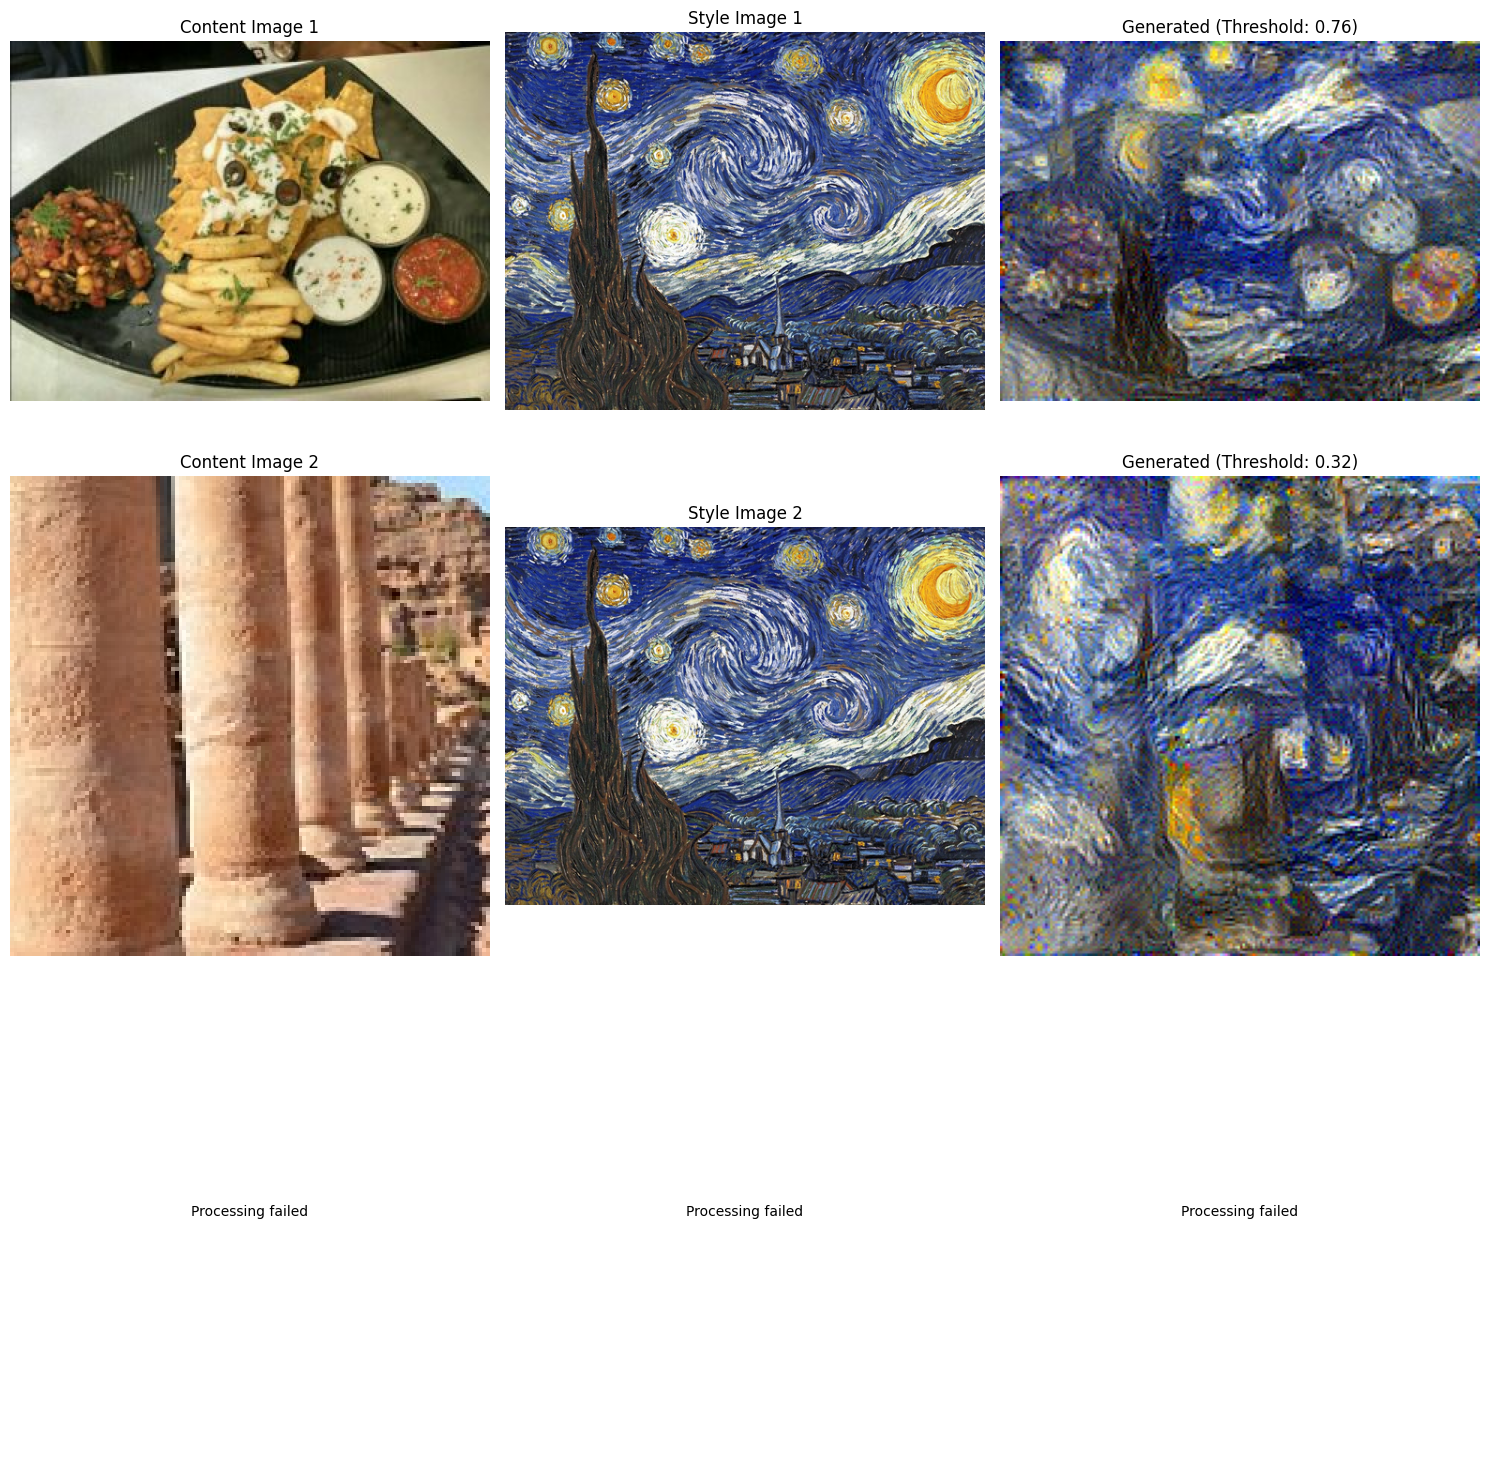

In [73]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import vgg19

# Generated image size - reduced for memory efficiency
RESIZE_HEIGHT = 256

# Reduced number of iterations for faster processing
NUM_ITER = 3000

# Weights of the different loss components
CONTENT_WEIGHT = 8e-4 
STYLE_WEIGHT = 8e-1 

# The layer to use for the content loss.
CONTENT_LAYER_NAME = "block5_conv2"

# List of layers to use for the style loss.
STYLE_LAYER_NAMES = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]

class StyleTransferDataset:
    def __init__(self, content_paths, style_paths, transform=None, threshold_range=(0.3, 0.8)):
        self.content_paths = content_paths
        self.style_paths = style_paths
        self.transform = transform
        self.threshold_range = threshold_range

    def __len__(self):
        return len(self.content_paths)

    def __getitem__(self, idx):
        content_img = Image.open(self.content_paths[idx]).convert("RGB")
        style_img = Image.open(random.choice(self.style_paths)).convert("RGB")
        
        # If transform is provided, apply it, otherwise just convert to numpy array
        if self.transform:
            content_tensor = self.transform(content_img)
            style_tensor = self.transform(style_img)
        else:
            content_tensor = np.array(content_img)
            style_tensor = np.array(style_img)
            
        threshold = random.uniform(*self.threshold_range)
        return content_img, style_img, threshold

def preprocess_image(img, target_height, target_width):
    # Check if img is a PIL Image
    if isinstance(img, Image.Image):
        img = img.resize((target_width, target_height), Image.LANCZOS)
        arr = np.array(img)
    else:
        # If it's already a numpy array, use PIL to resize it
        try:
            # Convert numpy array to PIL Image
            pil_img = Image.fromarray(np.uint8(img))
            pil_img = pil_img.resize((target_width, target_height), Image.LANCZOS)
            arr = np.array(pil_img)
        except Exception as e:
            print(f"Error resizing image: {e}")
            # Fall back to a smaller blank image if resize fails
            arr = np.zeros((target_height, target_width, 3), dtype=np.uint8)
    
    arr = np.expand_dims(arr, axis=0)
    arr = vgg19.preprocess_input(arr)
    return tf.convert_to_tensor(arr)

def get_model():
    # Build a VGG19 model loaded with pre-trained ImageNet weights
    model = vgg19.VGG19(weights='imagenet', include_top=False)

    # Get the symbolic outputs of each "key" layer (we gave them unique names).
    outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])

    # Set up a model that returns the activation values for every layer in VGG19 (as a dict).
    return keras.Model(inputs=model.inputs, outputs=outputs_dict)

def get_optimizer():
    return keras.optimizers.Adam(
        keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=8.0, decay_steps=445, decay_rate=0.98
        )
    )

def compute_loss(feature_extractor, combination_image, content_features, style_features, content_weight, style_weight):
    combination_features = feature_extractor(combination_image)
    loss_content = compute_content_loss(content_features, combination_features)
    loss_style = compute_style_loss(style_features, combination_features, combination_image.shape[1] * combination_image.shape[2])

    return content_weight * loss_content + style_weight * loss_style

def compute_content_loss(content_features, combination_features):
    original_image = content_features[CONTENT_LAYER_NAME]
    generated_image = combination_features[CONTENT_LAYER_NAME]

    return tf.reduce_sum(tf.square(generated_image - original_image)) / 2

def compute_style_loss(style_features, combination_features, combination_size):
    loss_style = 0

    for layer_name in STYLE_LAYER_NAMES:
        style_feature = style_features[layer_name][0]
        combination_feature = combination_features[layer_name][0]
        loss_style += style_loss(style_feature, combination_feature, combination_size) / len(STYLE_LAYER_NAMES)

    return loss_style

def style_loss(style_features, combination_features, combination_size):
    S = gram_matrix(style_features)
    C = gram_matrix(combination_features)
    channels = style_features.shape[2]
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (combination_size ** 2))

def gram_matrix(x):
   x = tf.transpose(x, (2, 0, 1))
   features = tf.reshape(x, (tf.shape(x)[0], -1))
   gram = tf.matmul(features, tf.transpose(features))
   return gram

def deprocess_image(tensor, result_height, result_width):
    tensor = tensor.numpy()
    tensor = tensor.reshape((result_height, result_width, 3))

    # Remove zero-center by mean pixel
    tensor[:, :, 0] += 103.939
    tensor[:, :, 1] += 116.779
    tensor[:, :, 2] += 123.680

    # 'BGR'->'RGB'
    tensor = tensor[:, :, ::-1]
    return np.clip(tensor, 0, 255).astype("uint8")

def style_transfer(content_img, style_img, threshold, result_height=128, result_width=128, num_iterations=500):
    try:
        # Preprocess images
        content_tensor = preprocess_image(content_img, result_height, result_width)
        style_tensor = preprocess_image(style_img, result_height, result_width)
        
        # Start with random noise
        generated_image = tf.Variable(tf.random.uniform(content_tensor.shape, dtype=tf.dtypes.float32))
        
        # Build model
        model = get_model()
        optimizer = get_optimizer()
        
        # Calculate content and style weights based on threshold
        # threshold controls the balance between content and style
        content_weight = CONTENT_WEIGHT * (1 - threshold)
        style_weight = STYLE_WEIGHT * threshold
        
        content_features = model(content_tensor)
        style_features = model(style_tensor)
        
        # Optimize result image
        for iter in range(num_iterations):
            with tf.GradientTape() as tape:
                loss = compute_loss(model, generated_image, content_features, style_features, content_weight, style_weight)
            
            grads = tape.gradient(loss, generated_image)
            
            if iter % 100 == 0:
                print(f"Sample iteration: {iter}, loss: {loss:.2f}")
                
            optimizer.apply_gradients([(grads, generated_image)])
        
        # Return the final generated image
        return deprocess_image(generated_image, result_height, result_width)
    except Exception as e:
        print(f"Error in style transfer: {e}")
        # Return a placeholder image on error
        return np.zeros((result_height, result_width, 3), dtype=np.uint8)

def load_style_image(url, transform):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert('RGB')
    return image  # Add batch dimension


style_url = "https://cdn.britannica.com/78/43678-050-F4DC8D93/Starry-Night-canvas-Vincent-van-Gogh-New-1889.jpg"
fixed_style_img = load_style_image(style_url, transform)


# Create the dataset
dataset = StyleTransferDataset(content_train, style_train, transform)

# Create a figure with 3 rows (one for each example) and 3 columns (content, style, result)
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

# Process examples from the dataset
successful_examples = 0

for i in range(min(len(dataset),2)):
    if successful_examples >= 3:
        break
        
    try:
        #content_img, style_img, threshold = dataset[i]
        content_img, _, threshold = dataset[i]
        style_img = fixed_style_img
        print(dataset)
        # Pre-resize images to a manageable size to avoid OOM
        if isinstance(content_img, Image.Image):
            # Keep aspect ratio but limit the maximum dimension
            content_img.thumbnail((512, 512), Image.LANCZOS)
            width, height = content_img.size
        else:
            # For numpy arrays
            height, width = content_img.shape[:2]
            if max(height, width) > 512:
                scale = 512 / max(height, width)
                new_h, new_w = int(height * scale), int(width * scale)
                pil_img = Image.fromarray(np.uint8(content_img))
                pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
                content_img = np.array(pil_img)
                height, width = content_img.shape[:2]
            
        if isinstance(style_img, Image.Image):
            style_img.thumbnail((512, 512), Image.LANCZOS)
        else:
            height_s, width_s = style_img.shape[:2]
            if max(height_s, width_s) > 512:
                scale = 512 / max(height_s, width_s)
                new_h, new_w = int(height_s * scale), int(width_s * scale)
                pil_img = Image.fromarray(np.uint8(style_img))
                pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)
                style_img = np.array(pil_img)
        
        # For the style transfer, use an even smaller size
        new_height = RESIZE_HEIGHT
        new_width = int(width * new_height / height)
        
        # Also limit width to prevent memory issues
        if new_width > 192:
            new_width = 192
            new_height = int(height * new_width / width)
        
        print(f"Processing example {i+1} - Image size: {new_width}x{new_height}, Threshold: {threshold:.2f}")
        
        # Perform style transfer with optimized parameters
        generated_img = style_transfer(
            content_img, 
            style_img, 
            threshold,
            result_height=new_height,
            result_width=new_width,
            num_iterations=NUM_ITER
        )
        
        # Display the three images in a row
        if isinstance(content_img, Image.Image):
            content_np = np.array(content_img)
        else:
            content_np = content_img
            
        if isinstance(style_img, Image.Image):
            style_np = np.array(style_img)
        else:
            style_np = style_img
        
        axs[successful_examples, 0].imshow(content_np)
        axs[successful_examples, 0].set_title(f"Content Image {successful_examples+1}")
        axs[successful_examples, 0].axis('off')
        
        axs[successful_examples, 1].imshow(style_np)
        axs[successful_examples, 1].set_title(f"Style Image {successful_examples+1}")
        axs[successful_examples, 1].axis('off')
        
        axs[successful_examples, 2].imshow(generated_img)
        axs[successful_examples, 2].set_title(f"Generated (Threshold: {threshold:.2f})")
        axs[successful_examples, 2].axis('off')
            
        successful_examples += 1
        
    except Exception as e:
        print(f"Error processing example {i}: {e}")
        continue

# Handle case where less than 3 examples were successful
for i in range(successful_examples, 3):
    for j in range(3):
        axs[i, j].axis('off')
        axs[i, j].text(0.5, 0.5, "Processing failed", ha='center', va='center')

plt.tight_layout()
plt.show()